In [1]:
import sys
from utils import export_mft
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pickle
import plotly.graph_objects as go


sys.path.append('..')
from config import DATA_PATH
from pathlib import Path

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

# get the fitted PCA model
with open("../data_prep/pkl-files/pca_model.pkl", "rb") as f:
    pca_full = pickle.load(f)

# get the train contours (raw trajectory data)
with open("../data_prep/pkl-files/train_contours.pkl", "rb") as f:
    train_contours = pickle.load(f)

# get the test contours (raw trajectory data)
with open("../data_prep/pkl-files/test_contours.pkl", "rb") as f:
    test_contours = pickle.load(f)

# get saved scaler
with open("../data_prep/pkl-files/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("loaded pca model, n_components available:", pca_full.n_components_)
print(f"loaded {len(train_contours)} train contours, {len(test_contours)} test contours")
print("imports completed!")

loaded pca model, n_components available: 100
loaded 19509 train contours, 2147 test contours
imports completed!


In [2]:
# load full contours and build resampled_trajectories for real training

with open("../data_prep/pkl-files/train_contours.pkl", "rb") as f:
    contours = pickle.load(f)

def resample_trajectory(freqs, n_points=100):
    if len(freqs) < 2:
        return None
    x_old = np.linspace(0, 1, len(freqs))
    x_new = np.linspace(0, 1, n_points)
    f = interp1d(x_old, freqs, kind="linear")
    return f(x_new)

train_resampled_trajectories = []
for key, data in contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        train_resampled_trajectories.append(result)

print(f"resampled {len(train_resampled_trajectories)} out of {len(contours)} trajectories")

test_resampled_trajectories = []
for key, data in test_contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        test_resampled_trajectories.append(result)

print(f"resampled {len(test_resampled_trajectories)} out of {len(test_contours)} test trajectories")

resampled 19509 out of 19509 trajectories
resampled 2147 out of 2147 test trajectories


In [3]:
import plotly.graph_objects as go

all_trajectories_arr = np.array(train_resampled_trajectories)
means = all_trajectories_arr.mean(axis=1, keepdims=True)
centered = all_trajectories_arr - means
pca_coords = pca_full.transform(centered)[:, :3]

fig = go.Figure(data=[go.Scatter3d(
    x=pca_coords[:, 0],
    y=pca_coords[:, 1],
    z=pca_coords[:, 2],
    mode='markers',
    marker=dict(size=2, opacity=0.4),
    text=[f"trajectory {i}" for i in range(len(pca_coords))],  # shows on hover
    hoverinfo='text'
)])

fig.update_layout(
    title="PCA space of all real USV trajectories",
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
    width=800, height=700
)

fig.show()

In [4]:
import plotly.graph_objects as go

fig_widget = go.FigureWidget(data=[go.Scatter3d(
    x=pca_coords[:, 0], y=pca_coords[:, 1], z=pca_coords[:, 2],
    mode='markers', marker=dict(size=2, opacity=0.4)
)])
fig_widget.update_layout(
    title="clickable version",
    scene=dict(xaxis_title="pc1", yaxis_title="pc2", zaxis_title="pc3"),
    width=800, height=700
)

def on_click(trace, points, state):
    if points.point_inds:
        idx = points.point_inds[0]
        traj = train_resampled_trajectories[idx]
        plt.figure(figsize=(6, 3))
        plt.plot(traj)
        plt.title(f"Trajectory {idx} (real)")
        plt.xlabel("timestep")
        plt.ylabel("frequency (Hz)")
        plt.show()

fig_widget.data[0].on_click(on_click)
fig_widget

FigureWidget({
    'data': [{'marker': {'opacity': 0.4, 'size': 2},
              'mode': 'markers',
              'type': 'scatter3d',
              'uid': '48a8286a-c959-465b-b5a9-cefe5f989d48',
              'x': {'bdata': ('AKDjZQgtxEB90E+gv3PBQBoxduOe09' ... 'VbMngB6kDvvwdH8PDuQFyXObY/Qu7A'),
                    'dtype': 'f8'},
              'y': {'bdata': ('Nw+o+PXrs8DAak65ULm2wE/tI9a/KN' ... 'JczDGZ50DunHSBP5zWQHWSLsjT+7ZA'),
                    'dtype': 'f8'},
              'z': {'bdata': ('8hEjW8ant8BEFelSiLy1wKZbIrzYzc' ... 'h//PrN1kCsLDckwizJQO2ouUUACbRA'),
                    'dtype': 'f8'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'pc1'}},
                         'yaxis': {'title': {'text': 'pc2'}},
                         'zaxis': {'title': {'text': 'pc3'}}},
               'template': '...',
               'title': {'text': 'clickable version'},
               'width': 800}
})

In [21]:
durations = []
mean_amplitudes = []
resampled_trajectories = []

for key, data in contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        resampled_trajectories.append(result)
        mean_amplitudes.append(np.nanmean(data["amplitude"]))
        durations.append(data["time_s"][-1] - data["time_s"][0])  # real duration in seconds

durations = np.array(durations)
mean_amplitudes = np.array(mean_amplitudes)

print(f"{len(durations)} durations computed, range: {durations.min():.4f}s to {durations.max():.4f}s")

19509 durations computed, range: 0.0037s to 0.2075s


In [22]:
all_trajectories_arr = np.array(resampled_trajectories)
means = all_trajectories_arr.mean(axis=1, keepdims=True)
centered = all_trajectories_arr - means
pca_coords_full = pca_full.transform(centered)[:, :10]

print("--- correlation between each of the 10 PCs and duration ---")
for i in range(10):
    corr = np.corrcoef(pca_coords_full[:, i], durations)[0, 1]
    print(f"PC{i+1} vs duration: correlation = {corr:.3f}")

--- correlation between each of the 10 PCs and duration ---
PC1 vs duration: correlation = 0.461
PC2 vs duration: correlation = 0.100
PC3 vs duration: correlation = -0.018
PC4 vs duration: correlation = 0.181
PC5 vs duration: correlation = -0.121
PC6 vs duration: correlation = -0.192
PC7 vs duration: correlation = -0.097
PC8 vs duration: correlation = -0.141
PC9 vs duration: correlation = 0.061
PC10 vs duration: correlation = -0.116


In [6]:
all_trajectories_arr = np.array(resampled_trajectories)
means = all_trajectories_arr.mean(axis=1, keepdims=True)
centered = all_trajectories_arr - means
pca_coords = pca_full.transform(centered)[:, :3]

In [19]:
pca_coords_full = pca_full.transform(centered)[:, :10]  # all 10 components, not js top 3

print("--- correlation between each of the 10 PCs and mean amplitude ---")
for i in range(10):
    corr = np.corrcoef(pca_coords_full[:, i], mean_amplitudes)[0, 1]
    print(f"PC{i+1} vs mean amplitude: correlation = {corr:.3f}")

--- correlation between each of the 10 PCs and mean amplitude ---
PC1 vs mean amplitude: correlation = 0.076
PC2 vs mean amplitude: correlation = 0.102
PC3 vs mean amplitude: correlation = 0.020
PC4 vs mean amplitude: correlation = 0.088
PC5 vs mean amplitude: correlation = -0.100
PC6 vs mean amplitude: correlation = -0.087
PC7 vs mean amplitude: correlation = -0.040
PC8 vs mean amplitude: correlation = -0.067
PC9 vs mean amplitude: correlation = 0.036
PC10 vs mean amplitude: correlation = -0.090


In [20]:
sample_key = list(contours.keys())[0]
print(contours[sample_key].keys())

dict_keys(['time_s', 'frequency_hz', 'amplitude'])


In [16]:
fig = go.Figure(data=[go.Scatter3d(
    x=pca_coords[:, 0], y=pca_coords[:, 1], z=pca_coords[:, 2],
    mode='markers',
    marker=dict(size=2, opacity=0.5, color=mean_amplitudes, colorscale='Viridis', colorbar=dict(title="mean amplitude")),
)])
fig.update_layout(
    title="PCA space colored by mean amplitude",
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
    width=1000, height=800
)
fig.show()

In [8]:
from sklearn.decomposition import PCA

X = np.stack(train_resampled_trajectories)
print("Data matrix shape:", X.shape)  # should be (19498, 100)

X_centered = X - X.mean(axis=1, keepdims=True)

pca_full = PCA()
pca_full.fit(X_centered)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative variance at 1, 2, 3, 5, 10 components:")
print(cumulative_variance[0], cumulative_variance[1], cumulative_variance[2], cumulative_variance[4], cumulative_variance[9])

Data matrix shape: (19509, 100)
Cumulative variance at 1, 2, 3, 5, 10 components:
0.46550167736109516 0.6849562277552433 0.7743043542934169 0.8625191489583517 0.9347618897198654


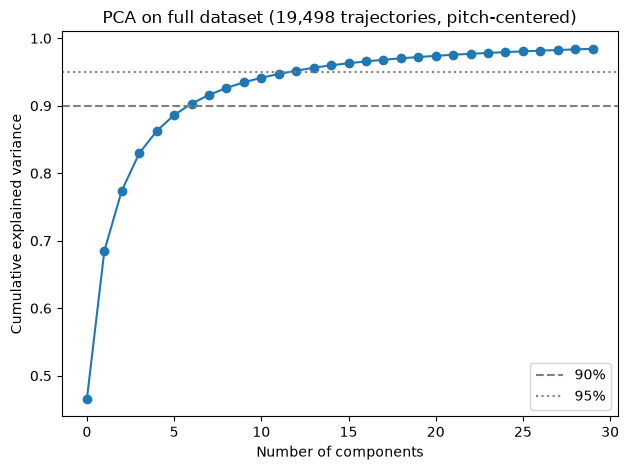

In [9]:
plt.plot(cumulative_variance[:30], marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='gray', linestyle='--', label='90%')
plt.axhline(0.95, color='gray', linestyle=':', label='95%')
plt.legend()
plt.title("PCA on full dataset (19,498 trajectories, pitch-centered)")
plt.tight_layout()
plt.show()

In [ ]:
# # TRAIN FILES
# # flag problem files
 
# from utils import flag_mft_dataset

# all_train_files = sorted(TRAIN_PATH.glob("*.WAV"))
# print(f"Total files: {len(all_train_files)}")

# flagged_df = flag_mft_dataset(all_train_files, output_csv="portable-data/flagged_mfts.csv")

Total files: 20265


/Users/ziyaahmad/Code/mouse_vocalization_2026/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1921
  warnings.warn(


Flagged 756 files.
Saved to: portable-data/flagged_mfts.csv


In [ ]:
# # exclude the flagged problem files, then extract + save real frequency
# # trajectories for all remaining clean files into one pickle file

# from utils import export_mft_pickle

# import pandas as pd

# flagged_df = pd.read_csv("portable-data/flagged_mfts.csv")
# print(f"Loaded {len(flagged_df)} flagged files")

# flagged_names = set(flagged_df["filename"])
# clean_files = [f for f in all_train_files if f.name not in flagged_names]
# print(f"Exporting {len(clean_files)} clean files")

# export_mft_pickle(clean_files, output_file="pkl-files/sep_24_contours.pkl")

Loaded 756 flagged files
Exporting 19509 clean files


/Users/ziyaahmad/Code/mouse_vocalization_2026/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1921
  warnings.warn(


'pkl-files/sep_24_contours.pkl'

In [ ]:
# # TEST FILES

# from utils import flag_mft_dataset

# all_test_files = sorted(TEST_PATH.glob("*.WAV"))
# print(f"Total test files: {len(all_test_files)}")

# flagged_test_df = flag_mft_dataset(all_test_files, output_csv="portable-data/flagged_test_mfts.csv")
# print(f"Flagged {len(flagged_test_df)} out of {len(all_test_files)}")

Total test files: 2251
Flagged 104 files.
Saved to: portable-data/flagged_test_mfts.csv
Flagged 104 out of 2251


In [ ]:
# # exclude flagged files, export the clean test set
# from utils import export_mft_pickle

# flagged_test_names = set(flagged_test_df["filename"])
# clean_test_files = [f for f in all_test_files if f.name not in flagged_test_names]
# print(f"Exporting {len(clean_test_files)} clean test files")

# export_mft_pickle(clean_test_files, output_file="pkl-files/sep_24_test_contours.pkl")

Exporting 2147 clean test files


'pkl-files/sep_24_test_contours.pkl'